# Experiment 9 - Generative Adversarial Networks
**Dataset:** Fashion-MNIST | **Models:** Vanilla GAN, DCGAN

In [1]:
!pip install wandb huggingface_hub -q

In [3]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aryanshukhla6 (aryanshukhla6-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
from huggingface_hub import notebook_login
notebook_login()

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "your-hf-username/exp9-gans"

WANDB_PROJECT = "exp9-gans"
EPOCHS        = 2
BATCH_SIZE    = 128
LATENT_DIM    = 100
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["bce", "lsgan", "wgan"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vanilla", "dcgan"]

print(DEVICE)

cuda


### Dataset

train: 60000  test: 10000


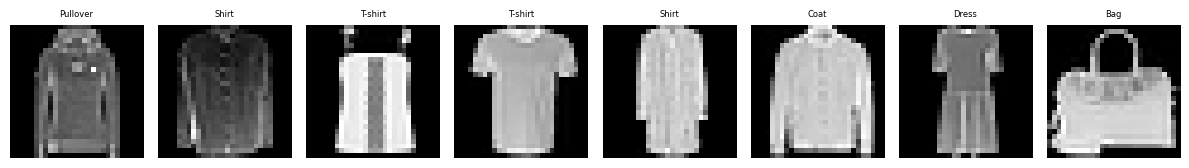

In [17]:
# normalize to [-1, 1] for GAN training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train: {len(train_data)}  test: {len(test_data)}')

imgs, labels = next(iter(train_loader))
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Vanilla GAN - Generator and Discriminator

In [8]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(VanillaGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super(VanillaDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

### DCGAN - Generator and Discriminator

In [18]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(DCGenerator, self).__init__()
        self.net = nn.Sequential(
            # latent -> 7x7x256
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 7x7 -> 14x14
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 14x14 -> 28x28
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7 -> 1x1
            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

### Loss Functions - BCE, LSGAN, WGAN

In [19]:
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

def disc_loss(real_out, fake_out, loss_type):
    if loss_type == 'bce':
        real_loss = bce(real_out, torch.ones_like(real_out))
        fake_loss = bce(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'lsgan':
        real_loss = mse(real_out, torch.ones_like(real_out))
        fake_loss = mse(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'wgan':
        return -(real_out.mean() - fake_out.mean())

def gen_loss(fake_out, loss_type):
    if loss_type == 'bce':
        return bce(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'lsgan':
        return mse(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'wgan':
        return -fake_out.mean()

### Optimizer Factory

In [20]:
def get_optimizer(model, name):
    if name == 'adam':
        # betas tuned for GAN stability
        return optim.Adam(model.parameters(), lr=2e-4, betas=(0.5, 0.999))
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    else:
        return optim.RMSprop(model.parameters(), lr=5e-5)

### Training Loop

In [21]:
def train_epoch(G, D, loader, opt_g, opt_d, loss_type):
    G.train(); D.train()
    g_running = 0
    d_running = 0

    for real, _ in loader:
        real = real.to(DEVICE)
        bs   = real.size(0)

        # train discriminator
        z         = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake      = G(z).detach()
        real_out  = D(real)
        fake_out  = D(fake)
        d_loss    = disc_loss(real_out, fake_out, loss_type)
        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # weight clipping for wgan
        if loss_type == 'wgan':
            for p in D.parameters():
                p.data.clamp_(-0.01, 0.01)

        # train generator
        z        = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake     = G(z)
        fake_out = D(fake)
        g_loss   = gen_loss(fake_out, loss_type)
        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        g_running += g_loss.item()
        d_running += d_loss.item()

    n = len(loader)
    return g_running / n, d_running / n

### Visualization

In [22]:
def show_generated(G, epoch, tag, n=16):
    G.eval()
    with torch.no_grad():
        z    = torch.randn(n, LATENT_DIM).to(DEVICE)
        imgs = G(z).cpu()
    imgs = (imgs + 1) / 2  # [-1,1] -> [0,1]
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'epoch {epoch} - {tag}', fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

### Main Experiment Runner

In [23]:
results       = {}
saved_generators = {}

def run_experiment(arch, loss_type, opt_name):
    name = f'{arch}_{loss_type}_{opt_name}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type, 'optimizer': opt_name, 'epochs': EPOCHS
    })

    if arch == 'vanilla':
        G = VanillaGenerator(LATENT_DIM).to(DEVICE)
        D = VanillaDiscriminator().to(DEVICE)
    else:
        G = DCGenerator(LATENT_DIM).to(DEVICE)
        D = DCDiscriminator().to(DEVICE)

    opt_g = get_optimizer(G, opt_name)
    opt_d = get_optimizer(D, opt_name)

    g_losses = []
    d_losses = []

    for epoch in range(1, EPOCHS + 1):
        g_loss, d_loss = train_epoch(G, D, train_loader, opt_g, opt_d, loss_type)
        g_losses.append(g_loss)
        d_losses.append(d_loss)
        wandb.log({'epoch': epoch, 'g_loss': g_loss, 'd_loss': d_loss})
        print(f'  epoch {epoch}/{EPOCHS}  g_loss={g_loss:.4f}  d_loss={d_loss:.4f}')

        if epoch % 5 == 0 or epoch == EPOCHS:
            fig = show_generated(G, epoch, name)
            wandb.log({f'generated_ep{epoch}': wandb.Image(fig)})
            plt.close(fig)

    # loss curves
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(g_losses, label='generator')
    ax.plot(d_losses, label='discriminator')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(name)
    ax.legend()
    plt.tight_layout()
    plt.show()
    wandb.log({'loss_curve': wandb.Image(fig)})
    plt.close(fig)

    torch.save(G.state_dict(), f'{name}_G.pt')
    torch.save(D.state_dict(), f'{name}_D.pt')
    saved_generators[name] = G
    results[name] = {'g_loss': g_losses[-1], 'd_loss': d_losses[-1]}

    wandb.finish()
    return G, D

### Quick Test - run this first


starting: vanilla_bce_adam


d_loss,▁
epoch,▁
g_loss,▁
d_loss,0.46505
epoch,1
g_loss,1.25284


  epoch 1/2  g_loss=1.1360  d_loss=0.4869
  epoch 2/2  g_loss=2.0486  d_loss=0.4376


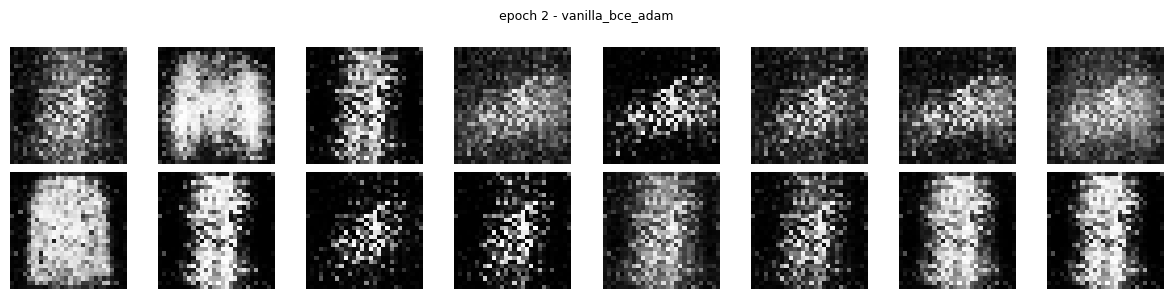

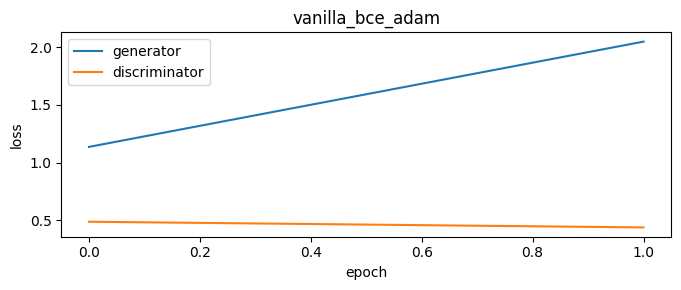

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.43756
epoch,2
g_loss,2.04859



starting: dcgan_bce_adam


  epoch 1/2  g_loss=1.2655  d_loss=0.4671
  epoch 2/2  g_loss=1.1758  d_loss=0.4844


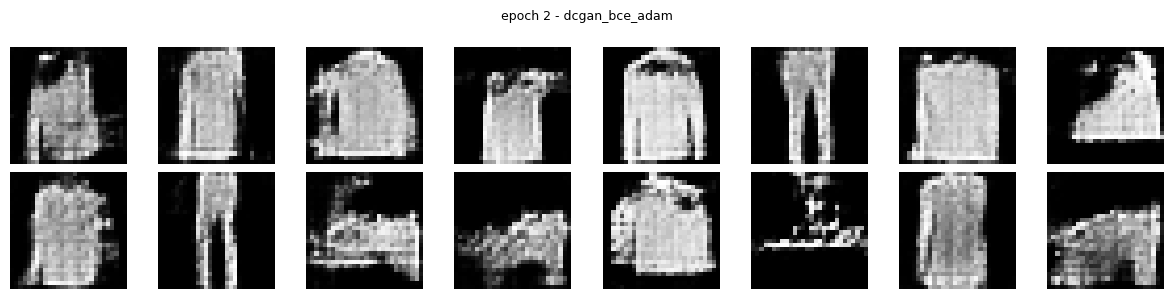

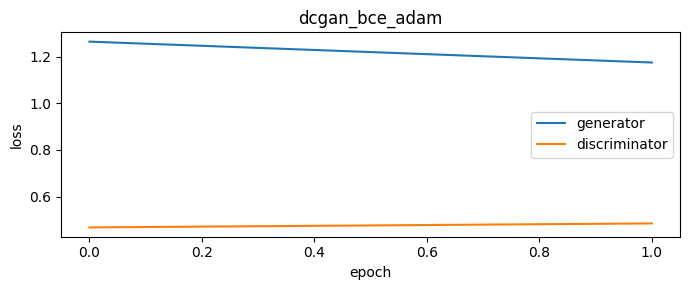

d_loss,▁█
epoch,▁█
g_loss,█▁
d_loss,0.48439
epoch,2
g_loss,1.17576


(DCGenerator(
   (net): Sequential(
     (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
     (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): ReLU(inplace=True)
     (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (7): Tanh()
   )
 ),
 DCDiscriminator(
   (net): Sequential(
     (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (1): LeakyReLU(negative_slope=0.2, inplace=True)
     (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (4): LeakyReLU(negative_slope=0.2, inplace=True)
    

In [24]:
run_experiment('vanilla', 'bce', 'adam')
run_experiment('dcgan',   'bce', 'adam')

### Full Grid - all combinations


starting: vanilla_bce_adam


  epoch 1/2  g_loss=1.1540  d_loss=0.4881
  epoch 2/2  g_loss=1.9053  d_loss=0.4443


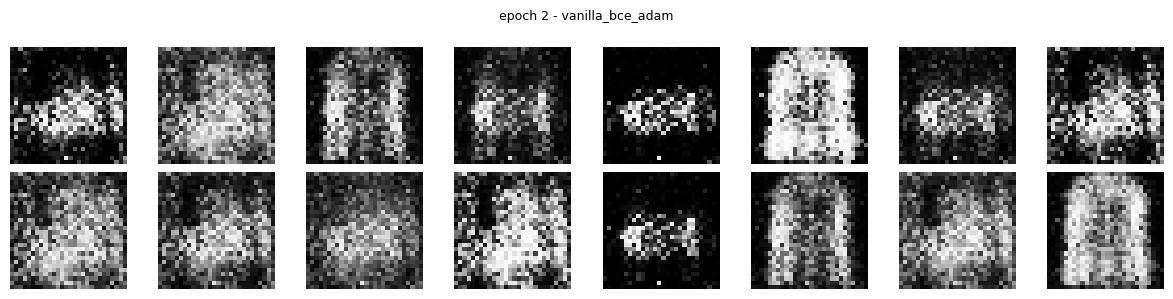

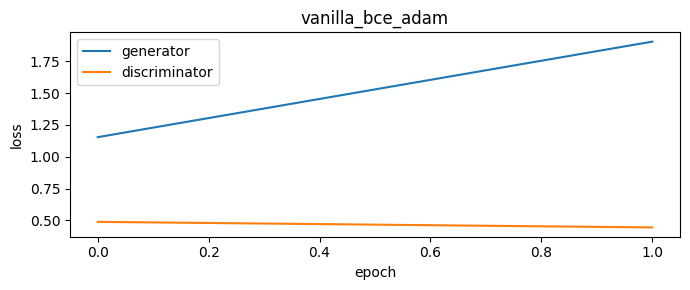

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.44427
epoch,2
g_loss,1.90526



starting: vanilla_bce_sgd


  epoch 1/2  g_loss=0.7978  d_loss=0.3709
  epoch 2/2  g_loss=1.5236  d_loss=0.2950


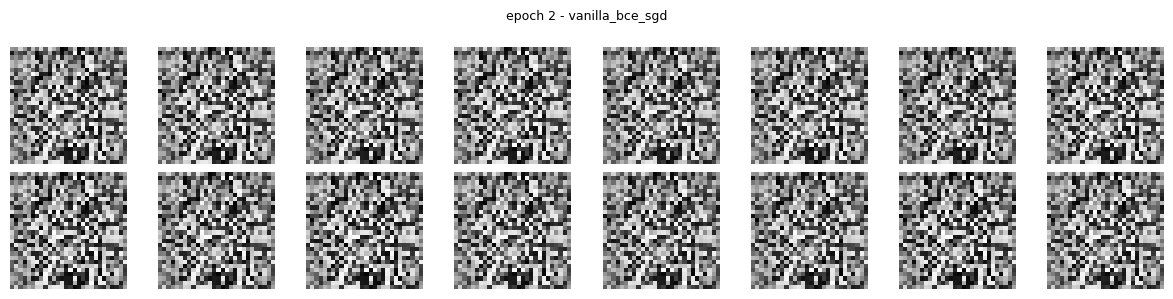

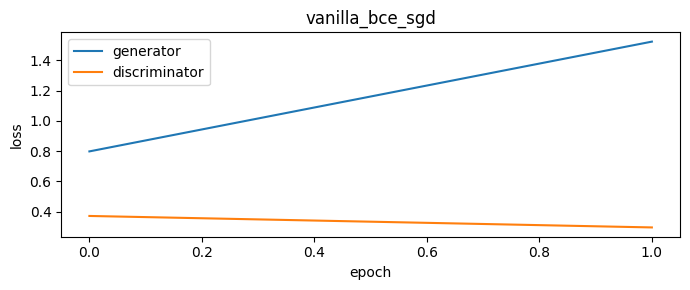

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.295
epoch,2
g_loss,1.52358



starting: vanilla_bce_rmsprop


  epoch 1/2  g_loss=0.8237  d_loss=0.4732
  epoch 2/2  g_loss=1.3708  d_loss=0.3732


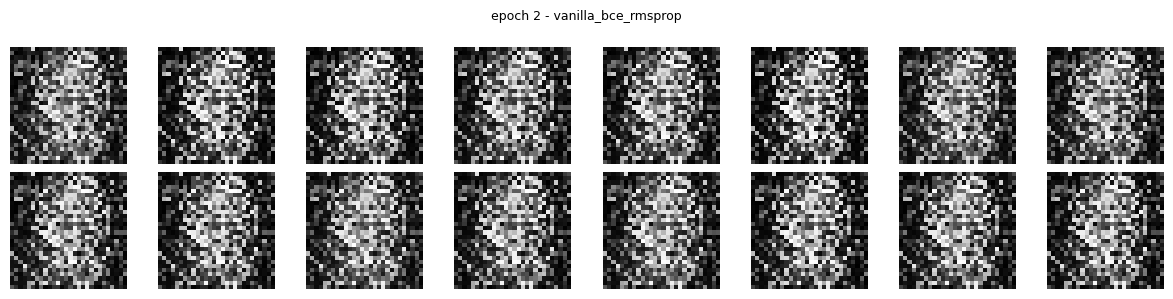

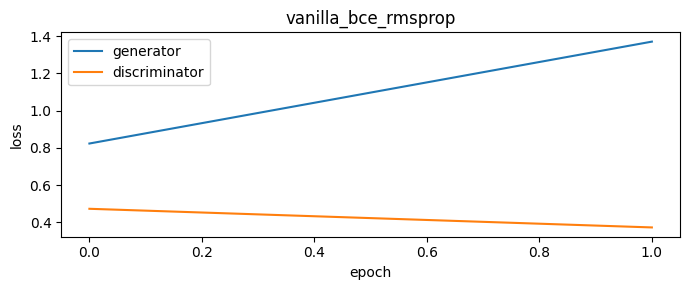

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.37315
epoch,2
g_loss,1.37076



starting: vanilla_lsgan_adam


  epoch 1/2  g_loss=0.9661  d_loss=0.0801
  epoch 2/2  g_loss=0.7841  d_loss=0.1264


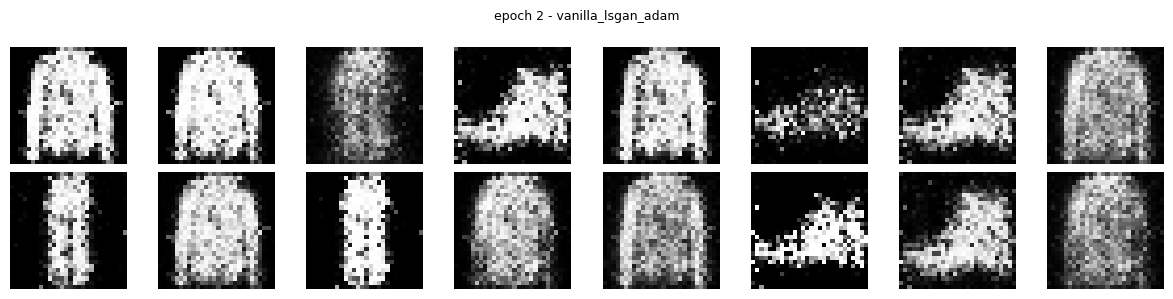

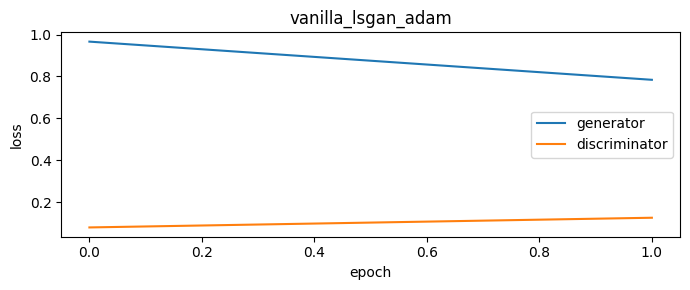

d_loss,▁█
epoch,▁█
g_loss,█▁
d_loss,0.12637
epoch,2
g_loss,0.78407



starting: vanilla_lsgan_sgd


  epoch 1/2  g_loss=0.7083  d_loss=0.0360
  epoch 2/2  g_loss=0.9919  d_loss=0.0343


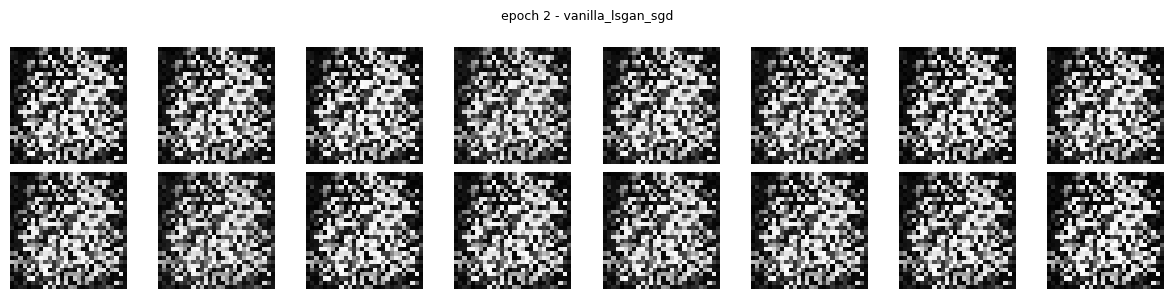

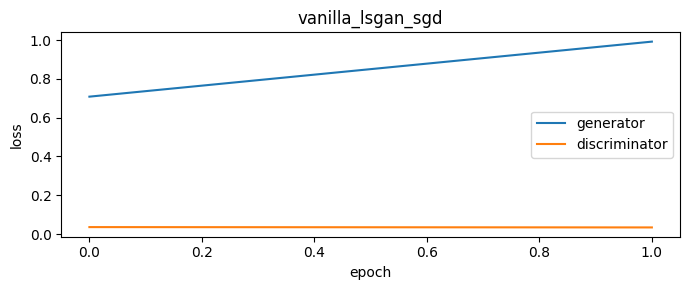

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.03426
epoch,2
g_loss,0.99189



starting: vanilla_lsgan_rmsprop


  epoch 1/2  g_loss=0.8512  d_loss=0.0685
  epoch 2/2  g_loss=0.9513  d_loss=0.0766


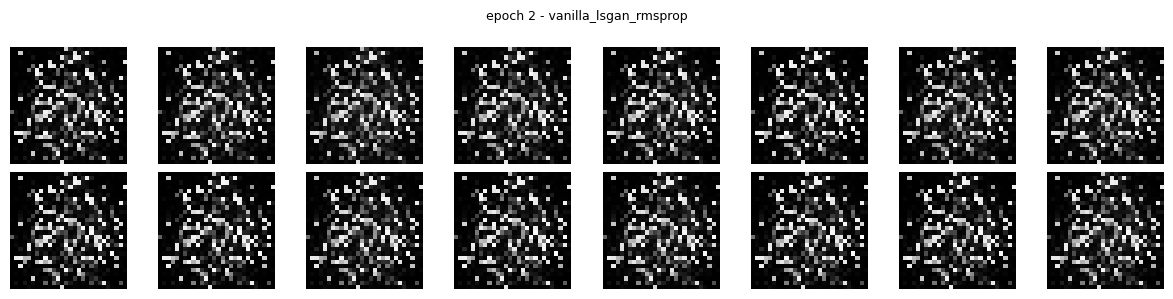

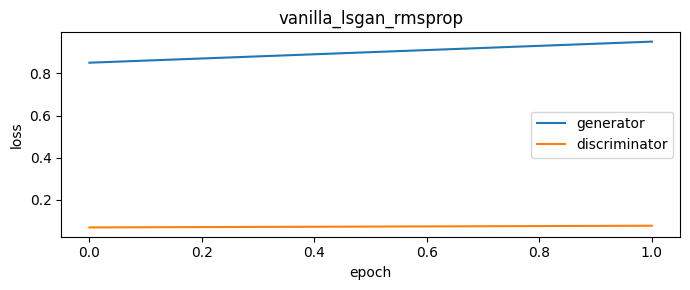

d_loss,▁█
epoch,▁█
g_loss,▁█
d_loss,0.07664
epoch,2
g_loss,0.95132



starting: vanilla_wgan_adam


  epoch 1/2  g_loss=-0.3901  d_loss=-0.4528
  epoch 2/2  g_loss=-0.4663  d_loss=-0.0922


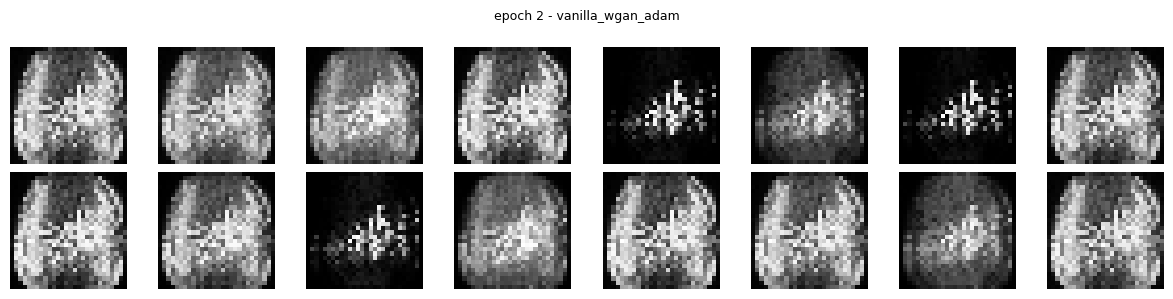

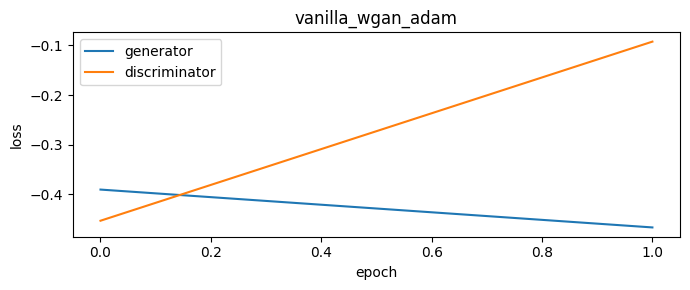

d_loss,▁█
epoch,▁█
g_loss,█▁
d_loss,-0.0922
epoch,2
g_loss,-0.46635



starting: vanilla_wgan_sgd


  epoch 1/2  g_loss=-0.3834  d_loss=-1.8582
  epoch 2/2  g_loss=2.3220  d_loss=-0.5611


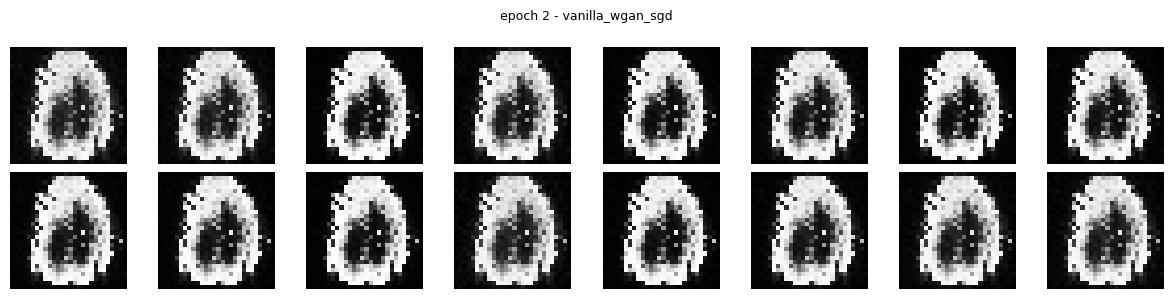

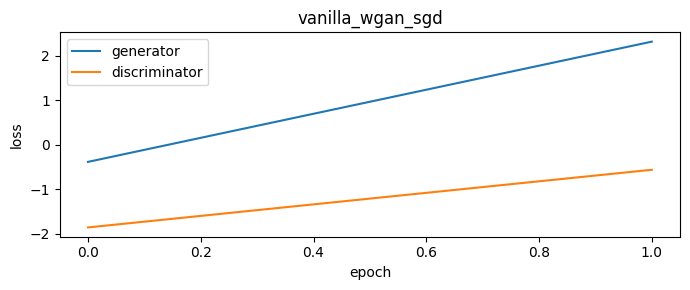

d_loss,▁█
epoch,▁█
g_loss,▁█
d_loss,-0.56115
epoch,2
g_loss,2.32202



starting: vanilla_wgan_rmsprop


  epoch 1/2  g_loss=-0.0380  d_loss=-0.1840
  epoch 2/2  g_loss=-0.3397  d_loss=-0.3336


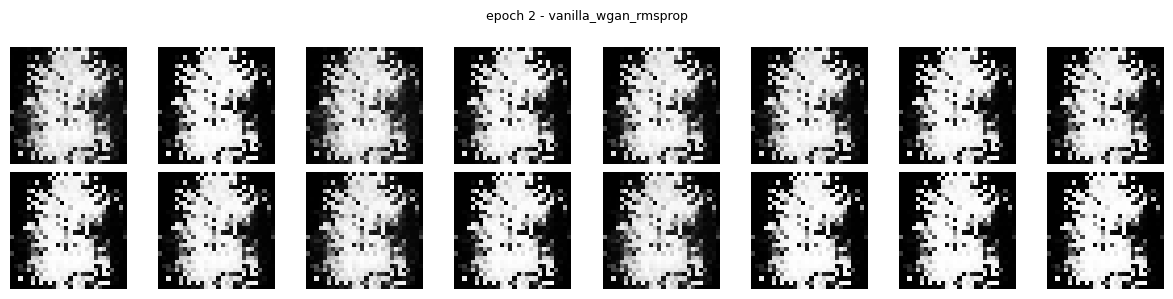

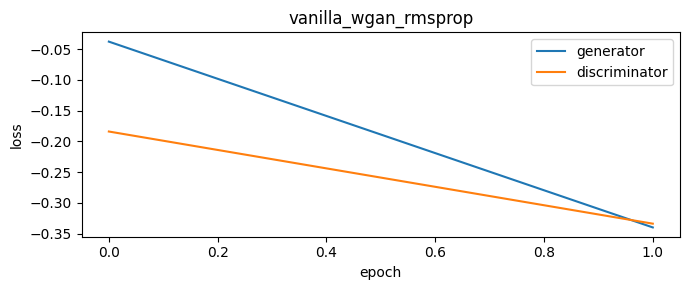

d_loss,█▁
epoch,▁█
g_loss,█▁
d_loss,-0.33363
epoch,2
g_loss,-0.33974



starting: dcgan_bce_adam


  epoch 1/2  g_loss=5.2246  d_loss=0.0432
  epoch 2/2  g_loss=7.5881  d_loss=0.0008


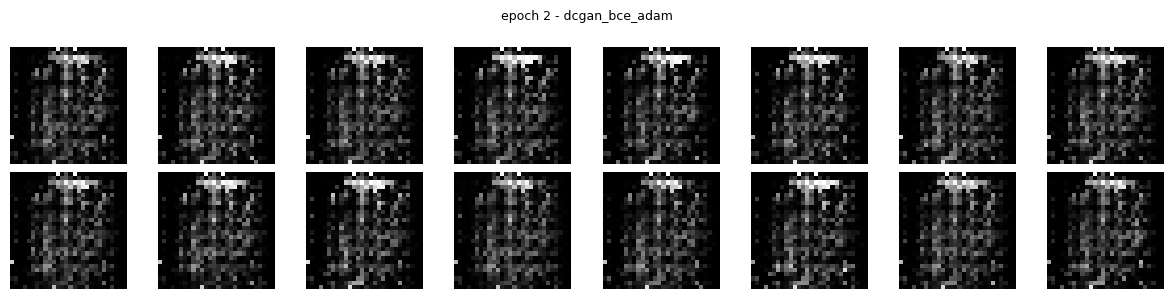

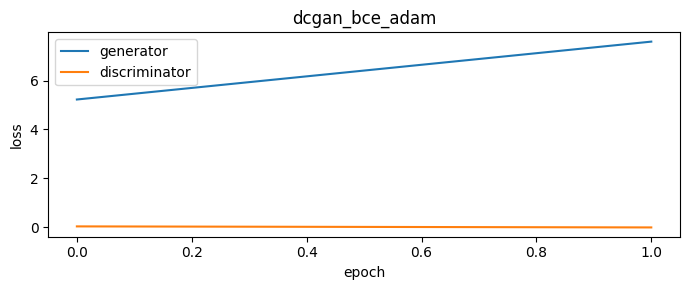

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.00075
epoch,2
g_loss,7.58805



starting: dcgan_bce_sgd


  epoch 1/2  g_loss=7.3334  d_loss=0.0278
  epoch 2/2  g_loss=7.3059  d_loss=0.0018


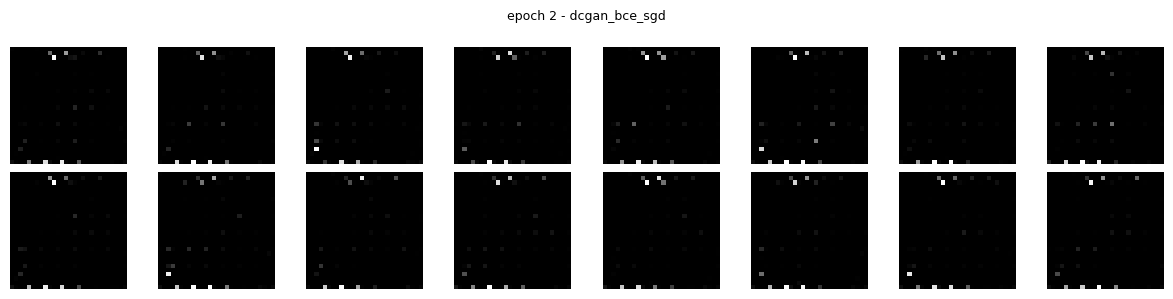

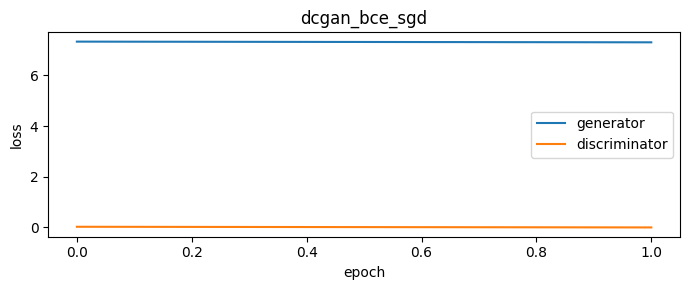

d_loss,█▁
epoch,▁█
g_loss,█▁
d_loss,0.00176
epoch,2
g_loss,7.30588



starting: dcgan_bce_rmsprop


  epoch 1/2  g_loss=5.0649  d_loss=0.0262
  epoch 2/2  g_loss=8.5034  d_loss=0.0004


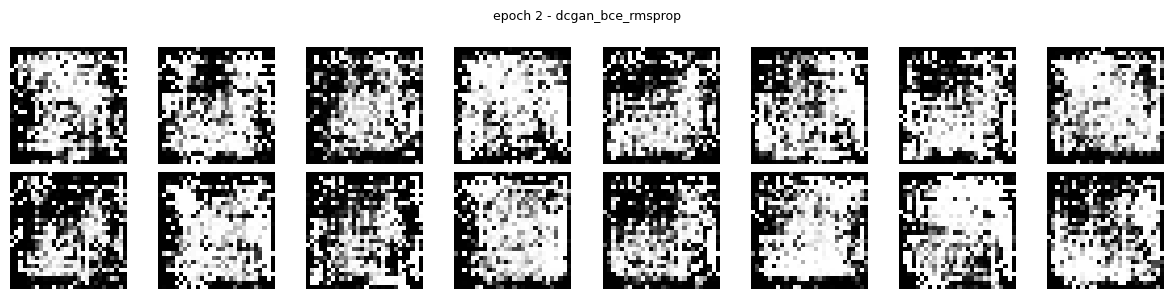

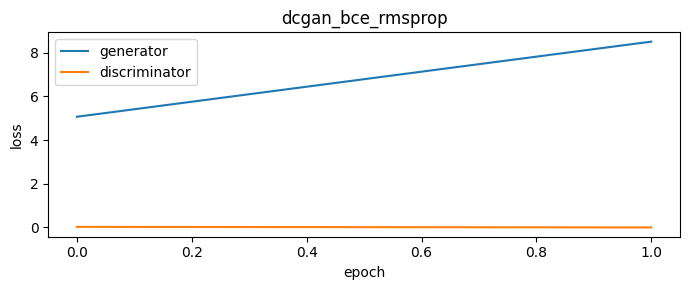

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.00035
epoch,2
g_loss,8.50335



starting: dcgan_lsgan_adam


  epoch 1/2  g_loss=0.6874  d_loss=0.1465
  epoch 2/2  g_loss=0.5703  d_loss=0.1454


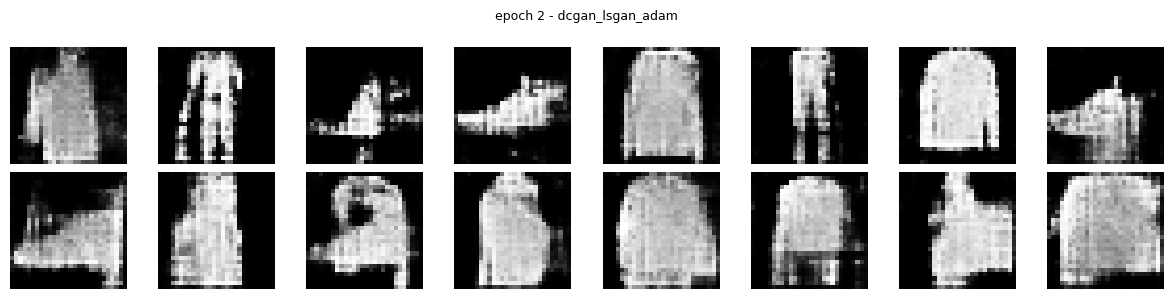

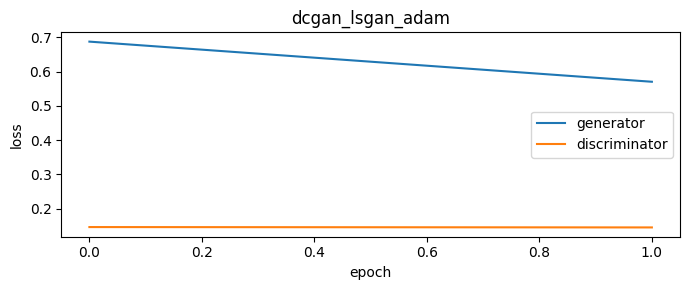

d_loss,█▁
epoch,▁█
g_loss,█▁
d_loss,0.14545
epoch,2
g_loss,0.57034



starting: dcgan_lsgan_sgd


  epoch 1/2  g_loss=1.2399  d_loss=0.1139
  epoch 2/2  g_loss=1.0060  d_loss=0.0047


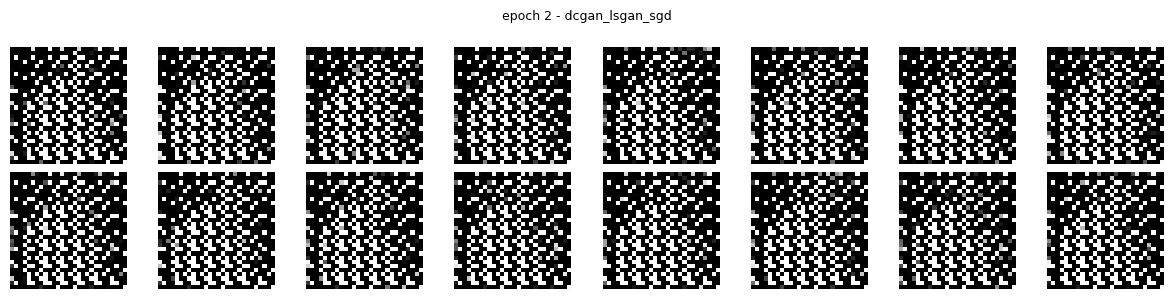

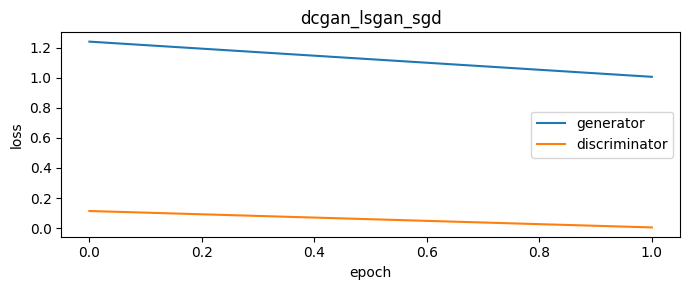

d_loss,█▁
epoch,▁█
g_loss,█▁
d_loss,0.00473
epoch,2
g_loss,1.00596



starting: dcgan_lsgan_rmsprop


  epoch 1/2  g_loss=1.0017  d_loss=0.0462
  epoch 2/2  g_loss=1.0096  d_loss=0.0171


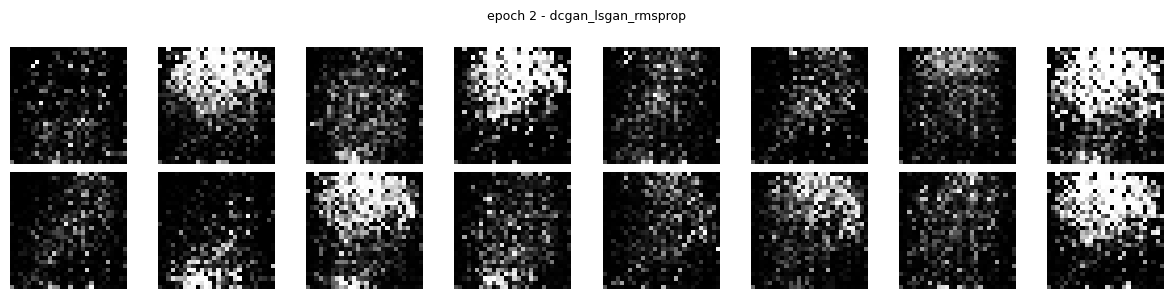

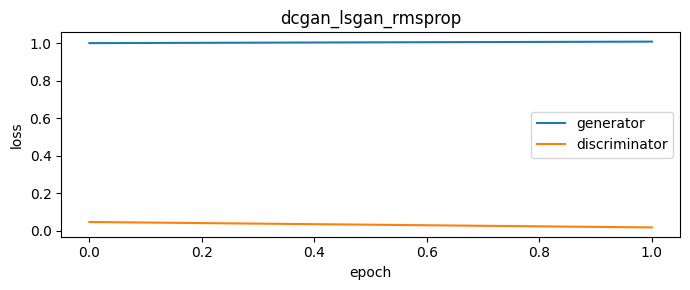

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.01711
epoch,2
g_loss,1.00961



starting: dcgan_wgan_adam


  epoch 1/2  g_loss=0.0430  d_loss=-0.0486
  epoch 2/2  g_loss=0.0303  d_loss=-0.0112


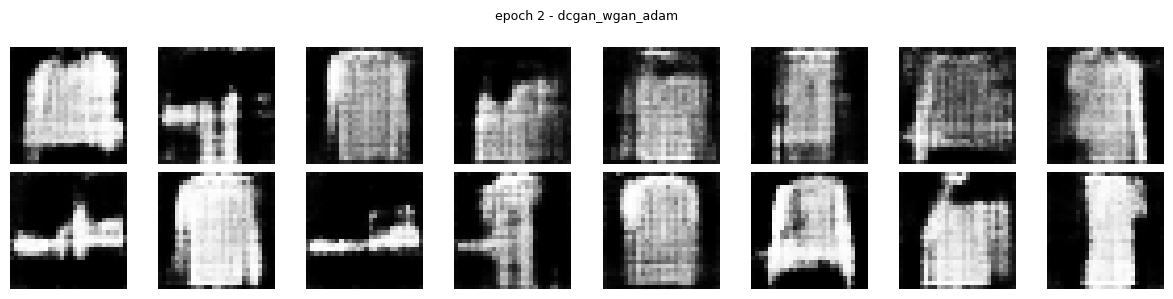

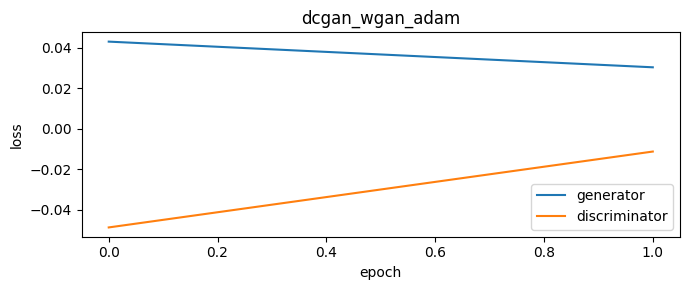

d_loss,▁█
epoch,▁█
g_loss,█▁
d_loss,-0.01123
epoch,2
g_loss,0.0303



starting: dcgan_wgan_sgd


  epoch 1/2  g_loss=0.2260  d_loss=-0.4405
  epoch 2/2  g_loss=0.4250  d_loss=-0.8125


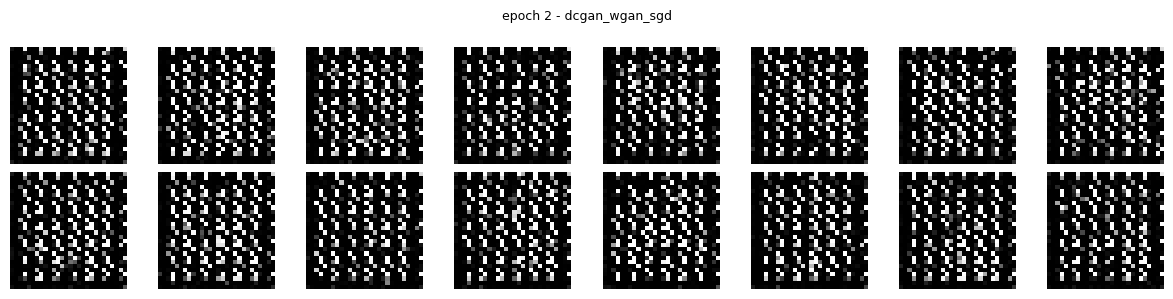

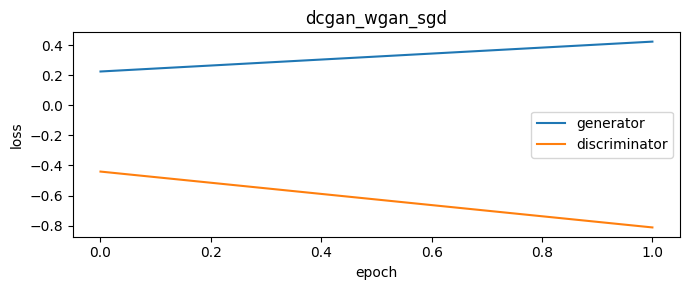

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,-0.81255
epoch,2
g_loss,0.42496



starting: dcgan_wgan_rmsprop


  epoch 1/2  g_loss=-0.0131  d_loss=-0.0029
  epoch 2/2  g_loss=-0.0050  d_loss=-0.0094


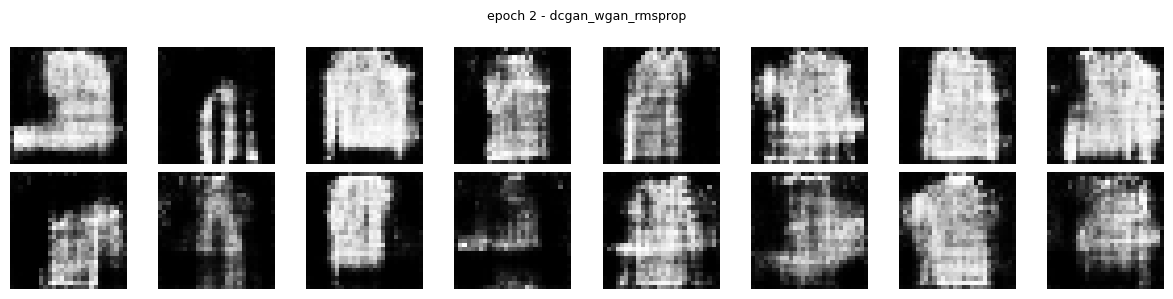

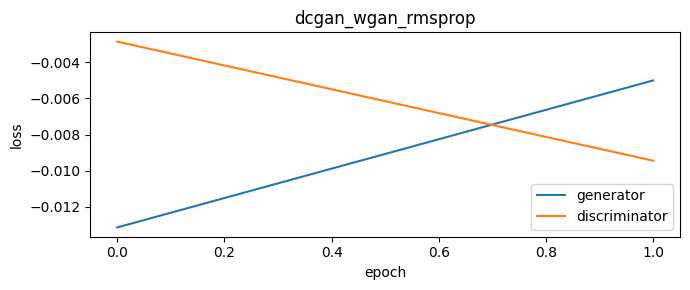

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,-0.00945
epoch,2
g_loss,-0.005


In [25]:
for arch in MODELS:
    for lf in LOSS_FNS:
        for opt in OPTIMIZERS:
            run_experiment(arch, lf, opt)

### Results Summary

In [26]:
print(f'{"config":<35} {"g_loss":>10} {"d_loss":>10}')
print('-' * 57)
for k, v in sorted(results.items(), key=lambda x: x[1]['g_loss']):
    print(f'{k:<35} {v["g_loss"]:>10.4f} {v["d_loss"]:>10.4f}')

config                                  g_loss     d_loss
---------------------------------------------------------
vanilla_wgan_adam                      -0.4663    -0.0922
vanilla_wgan_rmsprop                   -0.3397    -0.3336
dcgan_wgan_rmsprop                     -0.0050    -0.0094
dcgan_wgan_adam                         0.0303    -0.0112
dcgan_wgan_sgd                          0.4250    -0.8125
dcgan_lsgan_adam                        0.5703     0.1454
vanilla_lsgan_adam                      0.7841     0.1264
vanilla_lsgan_rmsprop                   0.9513     0.0766
vanilla_lsgan_sgd                       0.9919     0.0343
dcgan_lsgan_sgd                         1.0060     0.0047
dcgan_lsgan_rmsprop                     1.0096     0.0171
vanilla_bce_rmsprop                     1.3708     0.3732
vanilla_bce_sgd                         1.5236     0.2950
vanilla_bce_adam                        1.9053     0.4443
vanilla_wgan_sgd                        2.3220    -0.5611
dcgan_bce_sgd 